In [1]:
# Add imports 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist
from sspspace.sspspace.encoders import RandomSSPSpace

import nengo
from nengo.network import Network
from nengo import Node, Connection

from contrastive import CPCA


# Import the basal Ganglia model 
%load_ext autoreload
%autoreload 2
from bg_model import BasalGanglia
%load_ext autoreload
%autoreload 2
from utility import Utility, ActionIterator
%load_ext autoreload
%autoreload 2
from pca_analysis import Trial, Session, PCAAnalysis, cPCAAnalysis

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Helper Functions

In [58]:
# Helpers
# 1. for creating pdfs at different domain locations
def beta_with_peak(domain, peak, scale, k = 20.0):
     """
    Returns a Beta PDF over `domain` with its peak (mode) at the desired `peak` value.

    Parameters
    ----------
    domain : np.ndarray
        The domain over which the Beta distribution is evaluated.
    peak : float
        Desired location of the peak (must lie within domain range).
    scale : float
        The max value of the domain (upper bound of the Beta support).
    k : float
        Concentration parameter controlling sharpness (larger k = narrower peak).

    Returns
    -------
    pdf : np.ndarray
        The resulting Beta PDF values over `domain`.
    """
     
     low = float(domain.min())
     high = float(domain.max())
     assert low <= peak <= high, f"Peak {peak} must be within [{low}, {high}]"

     # Normalize peak to [0, 1]
     m = (peak - low)/ (high - low)

     # Convert desired mode m into alpha, beta parameters
     alpha = 1 + k * m
     beta = 1 + k * (1 - m)

     # Compute a PDF
     pdf = beta_dist.pdf(domain, alpha, beta, loc=low, scale=high-low)
     return pdf

def to_real(value):
    E = np.asarray(value)
    E = np.real_if_close(E).astype(np.float64)
    E[~np.isfinite(E)] = 0.0  
    return E

# Create the Distributions & Bundles

In [3]:
# ================================================
# 1. Define continuous force domain & SSP encoder
# ================================================
n_actions_park = 2
domain_force_park = np.arange(0, 15, 0.01).reshape(-1, 1) # Shape: (1500, 1)
ssp_dim_park = 512

# SSP encoder for scalar force values
ssp_encoder_park = RandomSSPSpace(
    domain_dim=1,
    ssp_dim=ssp_dim_park,
    rng=np.random.RandomState(0),
    length_scale=0.5
)
# Convert domain values to high-dimensional SSPs
domain_phis_park = ssp_encoder_park.encode(domain_force_park)  # shape: (1500, 512)
# print(domain_phis.shape)

# Place cell encoders for Nengo ensembles
low = 0
high = 15
width = high - low
places_park = np.arange(low, high, width/(domain_force_park.shape[0]))
dnf_encoders_park = np.asarray(ssp_encoder_park.encode(places_park.reshape(-1, 1))).squeeze() # Shape: (1500, 512)
# print(dnf_encoders.shape) # (512, 1500)

# ================================================
# 2. DNF Parameters
# ================================================
dnf_params_park = {
            'h'       : -3.009416816439706,
            'global_inh'      : 8.641108231311897,
            'tau'             : 0.04706404390267922,
            'exc'             : 9.421285790349613,
            'inh'             : 1.4841093480380807,
            'exc_w'           : 8.534993467227224,
            'inh_w'           : 4.748154014869723,
            'dt'              : 0.001, 
            'c_noise'         : 1.0,
            'shape'           : [(n_actions_park, 1500)], 
            'beta'            : 4,
    }



# ================================================
# 3. Generate two bundle vectors via Beta PDFs
# ================================================
# Define peak locations
peak_locations_left = [3, 3.25, 3.5, 3.75, 4]
peak_locations_right = [12, 12.25, 12.5, 12.75, 13]

# Generate beta PDFs
left_distributions = []
right_distributions = []
for i in range(len(peak_locations_left)):
    left_distributions.append(beta_with_peak(domain=domain_force_park, peak=peak_locations_left[i], scale=15, k=25))
    right_distributions.append(beta_with_peak(domain=domain_force_park, peak=peak_locations_right[i], scale=15, k=25))

# ========================================
# 4. Salience values for actions
# ========================================
salience_left = [0.9, 0.6]
salience_right = [0.6, 0.9]

# ========================================
# 5. Create bundles for the 5 sets of trials -- foreground data 
# ========================================
# In all cases left channel wins
left_t1 = Utility.to_bundle(Utility.to_scale(salience_left, Utility.to_normalize([left_distributions[0], right_distributions[0]])), domain_phis_park)
left_t2 = Utility.to_bundle(Utility.to_scale(salience_left, Utility.to_normalize([left_distributions[1], right_distributions[1]])), domain_phis_park)
left_t3 = Utility.to_bundle(Utility.to_scale(salience_left, Utility.to_normalize([left_distributions[2], right_distributions[2]])), domain_phis_park)
left_t4 = Utility.to_bundle(Utility.to_scale(salience_left, Utility.to_normalize([left_distributions[3], right_distributions[3]])), domain_phis_park)
left_t5 = Utility.to_bundle(Utility.to_scale(salience_left, Utility.to_normalize([left_distributions[4], right_distributions[4]])), domain_phis_park)
# In all cases right channel wins
right_t1 = Utility.to_bundle(Utility.to_scale(salience_right, Utility.to_normalize([left_distributions[0], right_distributions[0]])), domain_phis_park)
right_t2 = Utility.to_bundle(Utility.to_scale(salience_right, Utility.to_normalize([left_distributions[1], right_distributions[1]])), domain_phis_park)
right_t3 = Utility.to_bundle(Utility.to_scale(salience_right, Utility.to_normalize([left_distributions[2], right_distributions[2]])), domain_phis_park)
right_t4 = Utility.to_bundle(Utility.to_scale(salience_right, Utility.to_normalize([left_distributions[3], right_distributions[3]])), domain_phis_park)
right_t5 = Utility.to_bundle(Utility.to_scale(salience_right, Utility.to_normalize([left_distributions[4], right_distributions[4]])), domain_phis_park)

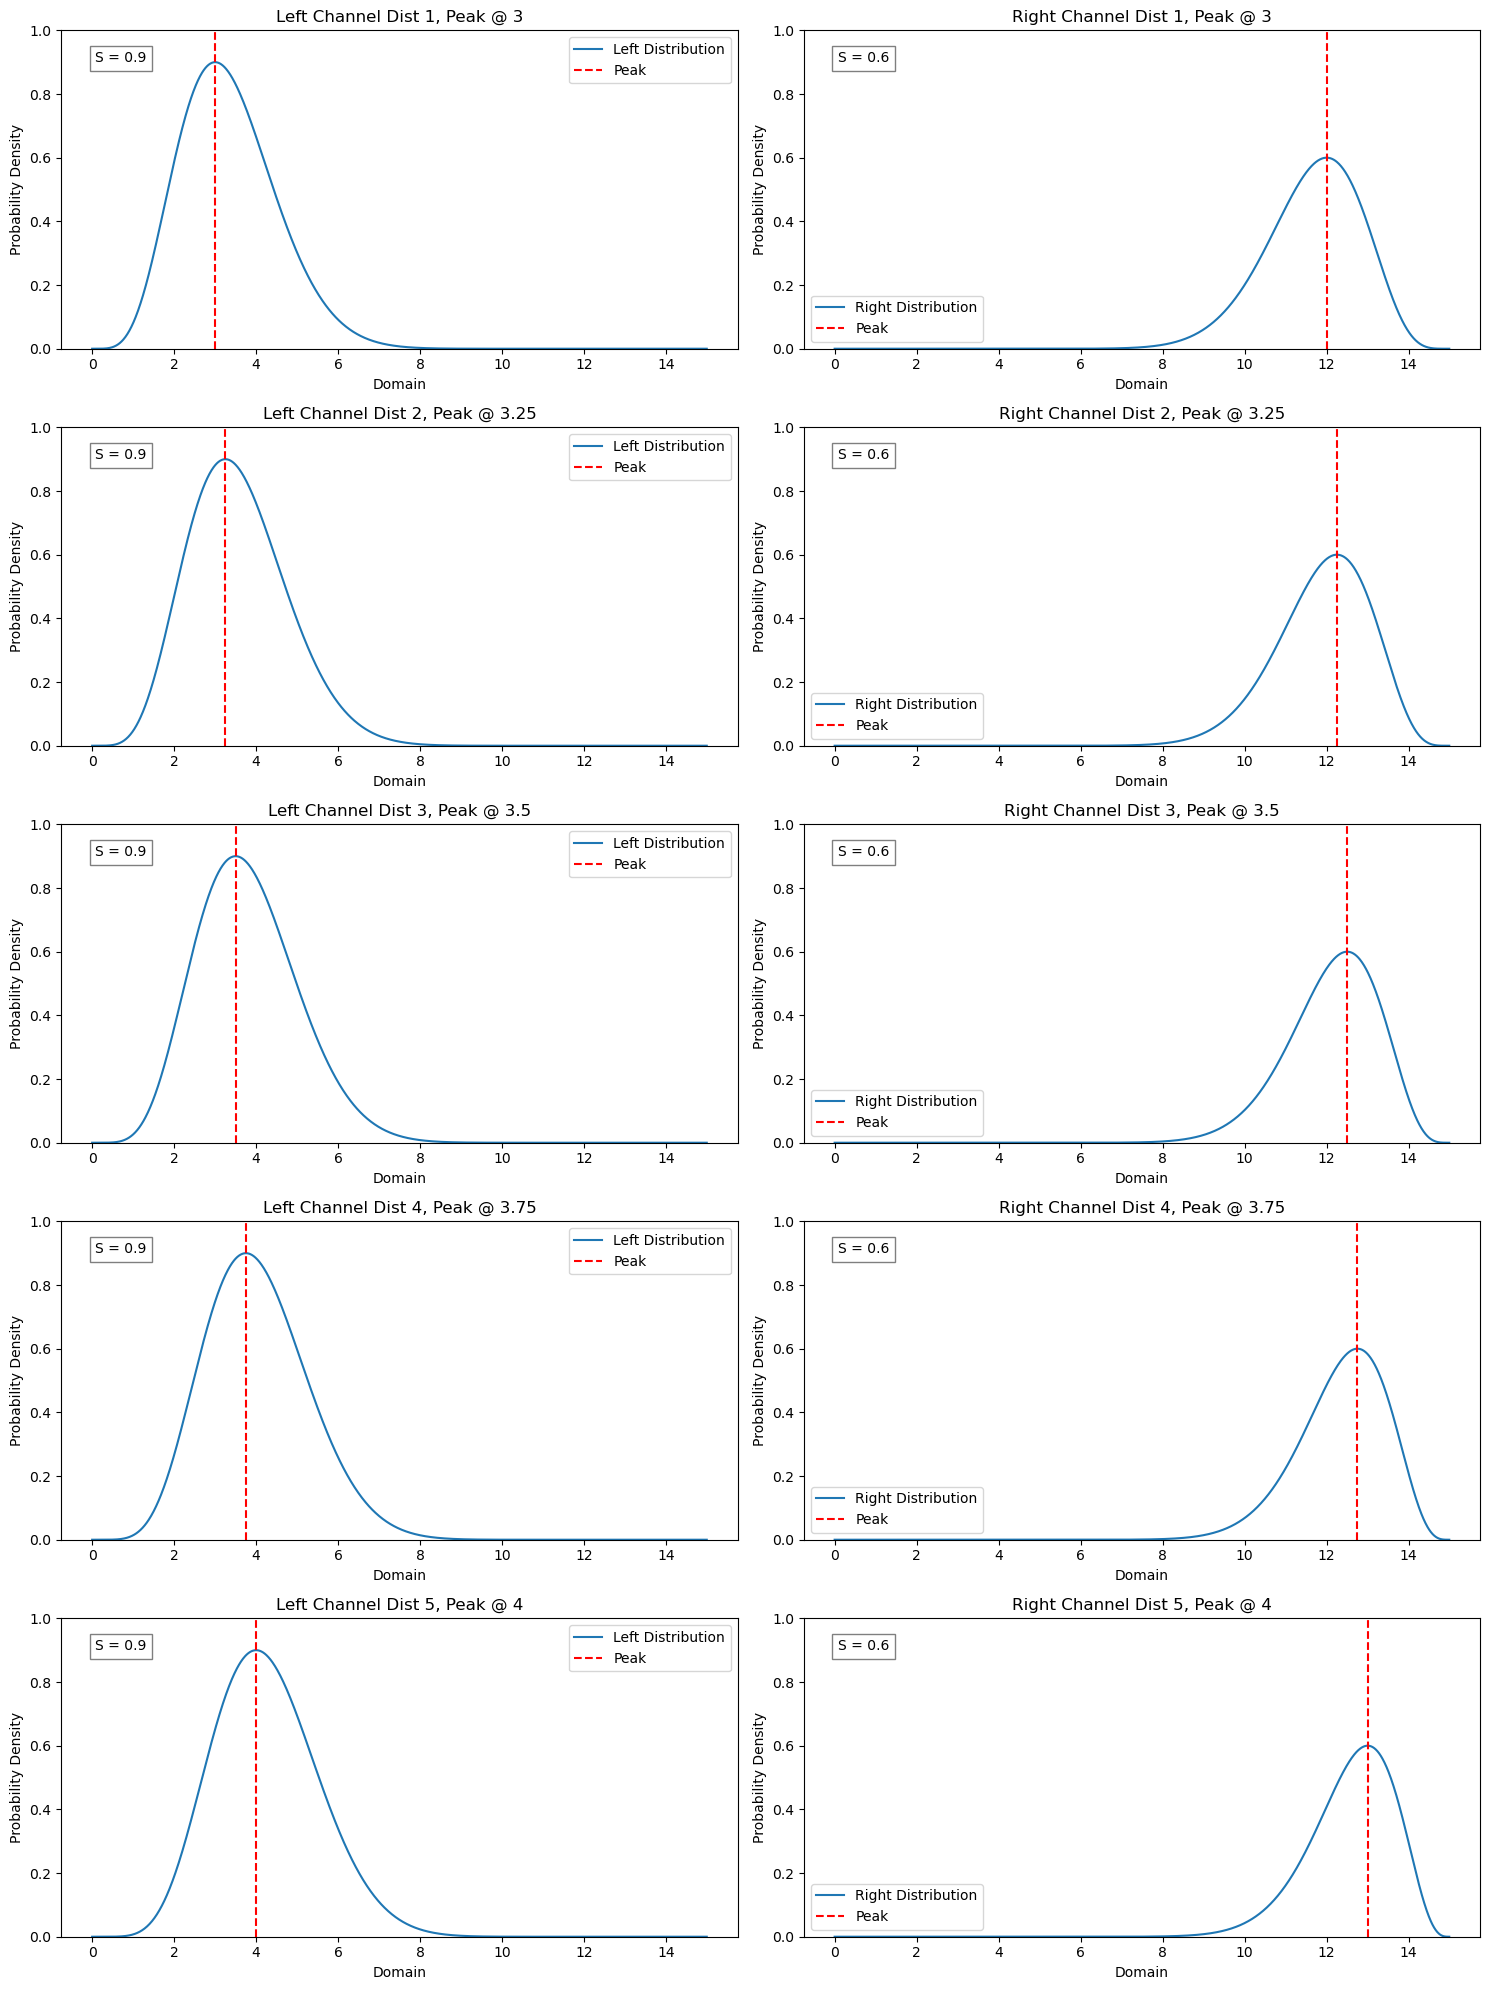

In [8]:
# For plotting:
salience_normalized_left1 = Utility.to_scale(salience=[0.9] * len(left_distributions), normalized_distributions=Utility.to_normalize(left_distributions))
salience_normalized_left2 = Utility.to_scale(salience=[0.6] * len(right_distributions), normalized_distributions=Utility.to_normalize(right_distributions))

# Plots = Left Channel wins! 
fig, axes = plt.subplots(5, 2, figsize=(15, 20),)

for i in range(len(peak_locations_left)):
    # Left channel plot (col 0)
    ax_left = axes[i, 0]
    dist_left = salience_normalized_left1[i]
    ax_left.plot(domain_force_park, dist_left, label='Left Distribution')
    ax_left.axvline(peak_locations_left[i], color='r', linestyle='--', label='Peak')
    ax_left.legend()
    ax_left.text(0.05, 0.9, f'S = 0.9', transform=ax_left.transAxes, fontsize=10,
                 bbox=dict(facecolor='white', alpha=0.5))
    ax_left.set_title(f'Left Channel Dist {i+1}, Peak @ {peak_locations_left[i]}')
    ax_left.set_xlabel('Domain')
    ax_left.set_ylabel('Probability Density')
    ax_left.set_ylim(0, 1.0)

    # Right channel plot (col 1)
    ax_right = axes[i, 1]
    dist_right = salience_normalized_left2[i]
    ax_right.plot(domain_force_park, dist_right, label='Right Distribution')
    ax_right.axvline(peak_locations_right[i], color='r', linestyle='--', label='Peak')
    ax_right.legend()
    ax_right.text(0.05, 0.9, f'S = 0.6', transform=ax_right.transAxes, fontsize=10,
                  bbox=dict(facecolor='white', alpha=0.5))
    ax_right.set_title(f'Right Channel Dist {i+1}, Peak @ {peak_locations_left[i]}')
    ax_right.set_xlabel('Domain')
    ax_right.set_ylabel('Probability Density')
    ax_right.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()



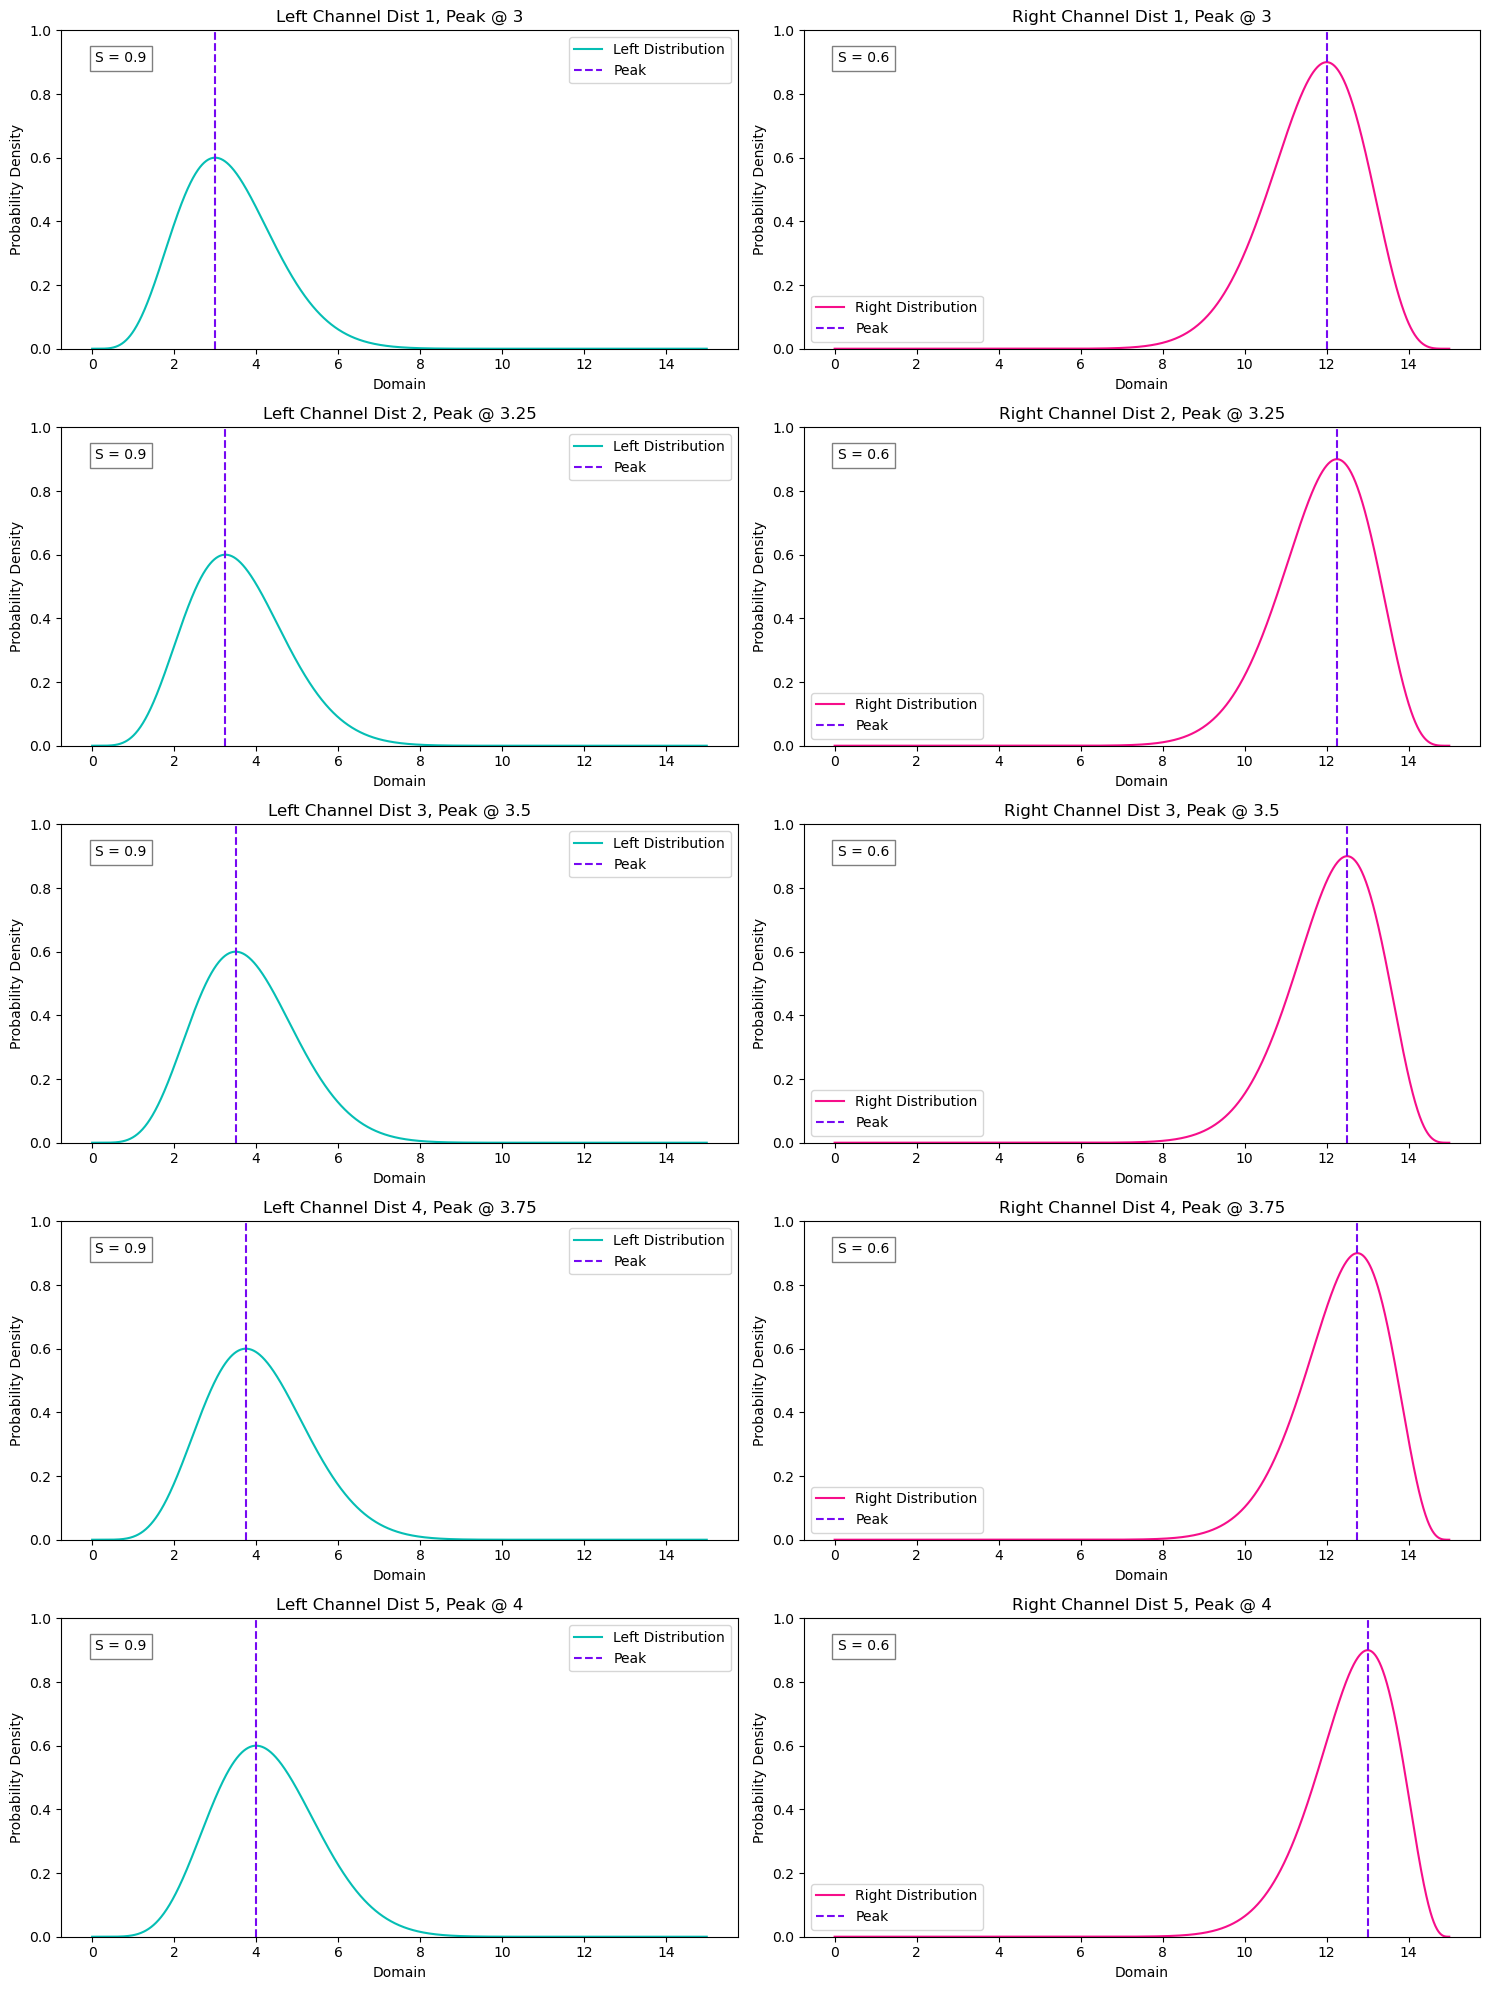

In [9]:
# For plotting:
salience_normalized_right1 = Utility.to_scale(salience=[0.6] * len(left_distributions), normalized_distributions=Utility.to_normalize(left_distributions))
salience_normalized_right2 = Utility.to_scale(salience=[0.9] * len(right_distributions), normalized_distributions=Utility.to_normalize(right_distributions))

# Plots = Right Channel wins! 
fig, axes = plt.subplots(5, 2, figsize=(15, 20),)

for i in range(len(peak_locations_left)):
    # Left channel plot (col 0)
    ax_left = axes[i, 0]
    dist_left = salience_normalized_right1[i]
    ax_left.plot(domain_force_park, dist_left, color = '#05beb4', label='Left Distribution')
    ax_left.axvline(peak_locations_left[i], color='#7609f2', linestyle='--', label='Peak')
    ax_left.legend()
    ax_left.text(0.05, 0.9, f'S = 0.9', transform=ax_left.transAxes, fontsize=10,
                 bbox=dict(facecolor='white', alpha=0.5))
    ax_left.set_title(f'Left Channel Dist {i+1}, Peak @ {peak_locations_left[i]}')
    ax_left.set_xlabel('Domain')
    ax_left.set_ylabel('Probability Density')
    ax_left.set_ylim(0, 1.0)

    # Right channel plot (col 1)
    ax_right = axes[i, 1]
    dist_right = salience_normalized_right2[i]
    ax_right.plot(domain_force_park, dist_right, color = '#f60c89fd', label='Right Distribution')
    ax_right.axvline(peak_locations_right[i], color='#7609f2', linestyle='--', label='Peak')
    ax_right.legend()
    ax_right.text(0.05, 0.9, f'S = 0.6', transform=ax_right.transAxes, fontsize=10,
                  bbox=dict(facecolor='white', alpha=0.5))
    ax_right.set_title(f'Right Channel Dist {i+1}, Peak @ {peak_locations_left[i]}')
    ax_right.set_xlabel('Domain')
    ax_right.set_ylabel('Probability Density')
    ax_right.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()


In [10]:
# Run the TRAILS - LEFT CHANNEL WINS!
# BG Model 
bg_model = BasalGanglia(n_actions=2, dnf_parameters=dnf_params_park, encoders=dnf_encoders_park, dnf_neurons=1500)

# Left channel Wins
sim_left_t1 = bg_model.simulate(input_bundles=left_t1, dopamine_level=0.2, presentation_time=0.8, duration=1.0) 
sim_left_t2 = bg_model.simulate(input_bundles=left_t2, dopamine_level=0.2, presentation_time=0.8, duration=1.0) 
sim_left_t3 = bg_model.simulate(input_bundles=left_t3, dopamine_level=0.2, presentation_time=0.8, duration=1.0) 
sim_left_t4 = bg_model.simulate(input_bundles=left_t4, dopamine_level=0.2, presentation_time=0.8, duration=1.0) 
sim_left_t5 = bg_model.simulate(input_bundles=left_t5, dopamine_level=0.2, presentation_time=0.8, duration=1.0) 


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

/Users/priyadarshinisaha/anaconda3/envs/bgmodel/lib/python3.10/site-packages/nengo/neurons.py:489: RuntimeWarning: overflow encountered in exp
  output[...] = (1.0 / self.tau_ref) / (1 + np.exp(-J))


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

...

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

In [39]:
# Simulate background noise
noise_t1 = bg_model.simulate_noise(duration=1.0, high=10.0, rms=1.0, seed=1)
noise_t2 = bg_model.simulate_noise(duration=1.0, high=10.0, rms=1.0, seed=2)
noise_t3 = bg_model.simulate_noise(duration=1.0, high=10.0, rms=1.0, seed=3)
noise_t4 = bg_model.simulate_noise(duration=1.0, high=10.0, rms=1.0, seed=4)
noise_t5 = bg_model.simulate_noise(duration=1.0, high=10.0, rms=1.0, seed=5)

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

In [ ]:
# Right channel Wins
sim_right_t1 = bg_model.simulate(input_bundles=right_t1, dopamine_level=0.2, presentation_time=0.8, duration=1.0) 
sim_right_t2 = bg_model.simulate(input_bundles=right_t2, dopamine_level=0.2, presentation_time=0.8, duration=1.0) 
sim_right_t3 = bg_model.simulate(input_bundles=right_t3, dopamine_level=0.2, presentation_time=0.8, duration=1.0) 
sim_right_t4 = bg_model.simulate(input_bundles=right_t4, dopamine_level=0.2, presentation_time=0.8, duration=1.0) 
sim_right_t5 = bg_model.simulate(input_bundles=right_t5, dopamine_level=0.2, presentation_time=0.8, duration=1.0) 

In [40]:
# data Format
left3 = sim_left_t1['d1_neuron'][:, :1500] # shape: (1000, 1500)
left325 = sim_left_t2['d1_neuron'][:, :1500]
left350 = sim_left_t3['d1_neuron'][:, :1500]
left375 = sim_left_t4['d1_neuron'][:, :1500]
left4 = sim_left_t5['d1_neuron'][:, :1500]

noise3 = noise_t1['d1_neuron'][:, :1500]
noise325 = noise_t2['d1_neuron'][:, :1500]
noise350 = noise_t3['d1_neuron'][:, :1500]
noise375 = noise_t4['d1_neuron'][:, :1500]
noise4 = noise_t5['d1_neuron'][:, :1500]

left_target = np.vstack([left3, left325, left350, left375, left4]) # shape: (5000, 1500)
left_labels = (left3.shape[0]) * [3] + (left325.shape[0]) * [3.25] + (left350.shape[0]) * [3.50] + (left375.shape[0]) * [3.75] + (left4.shape[0]) * [4.0]
background = np.vstack([noise3, noise325, noise350, noise375, noise4])

In [ ]:
# PCA - left channel 
pca_model = PCAAnalysis(n_components=3)
left_channel_pca = pca_model.pca(data=left_target) # 5000, 3


In [ ]:
# cPCA left channel
mdl = CPCA(n_components=3, standardize=True)
projected_data_left, alpha_left = mdl.fit_transform(foreground=left_target, background=background, active_labels=left_labels, return_alphas=True)
# Shape: (5000, 3, 4)

In [56]:
alpha_left

array([  0.        ,  11.25335583,  74.43803013, 492.38826317])

In [57]:
projected_data_left[0].shape

(5000, 3)

(2, 4)


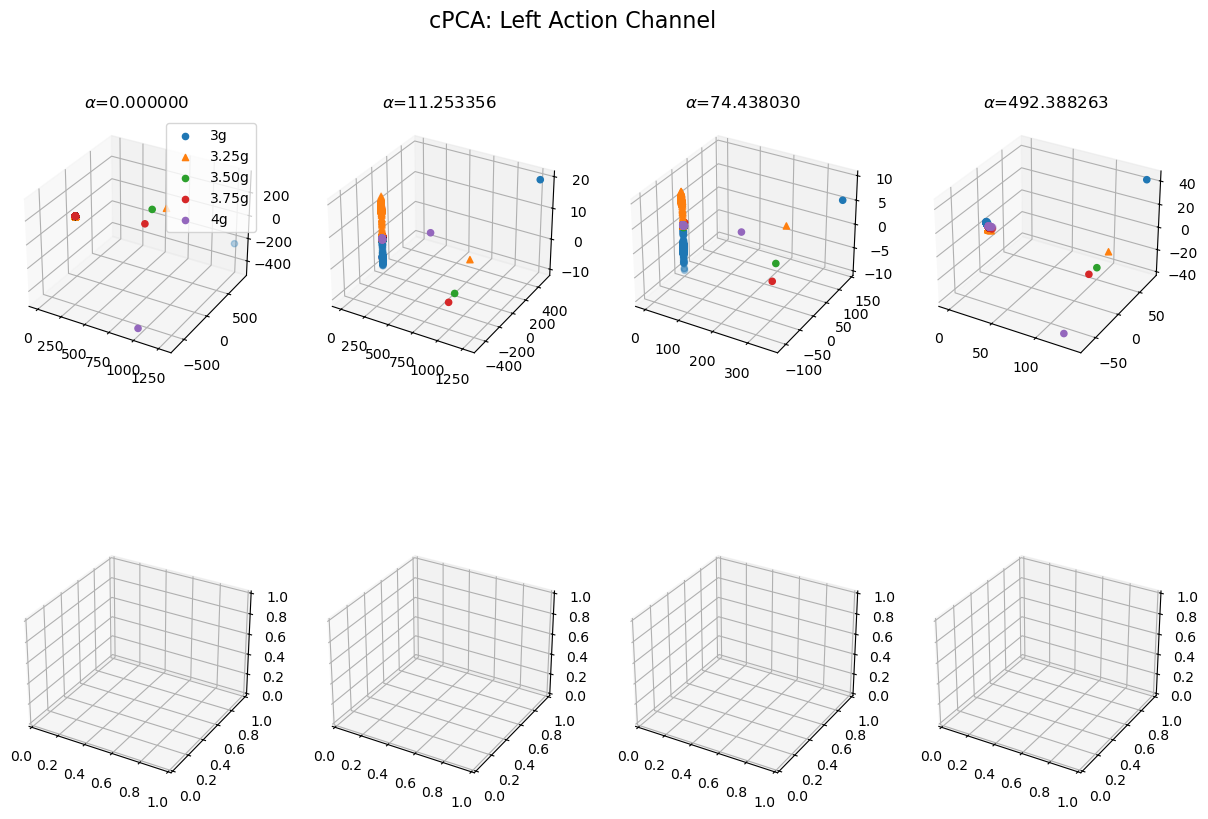

In [67]:
# Plot cPCA
fig, axes = plt.subplots(2, len(alpha_left), subplot_kw={'projection': '3d'}, figsize=(15, 10))
print(axes.shape)
def projected_data_3dplots(axes, data, alphas, labels, titles):
    for i in range(len(alphas)):
        # convert the data into real data 
        X = to_real(data[i])
        graph_labels = np.asarray(labels)
        f3 = graph_labels == 3
        f325 = graph_labels == 3.25
        f350 = graph_labels == 3.50
        f375 = graph_labels == 3.75
        f4 = graph_labels == 4

        # plot 
        axes[i].scatter(X[f3, 0],  X[f3, 1],  X[f3, 2],  label='3g',  marker='o')
        axes[i].scatter(X[f325, 0], X[f325, 1], X[f325, 2], label='3.25g', marker='^')
        axes[i].scatter(X[f350, 0], X[f350, 1], X[f350, 2], label='3.50g', marker='o')
        axes[i].scatter(X[f375, 0], X[f375, 1], X[f375, 2], label='3.75g', marker='o')
        axes[i].scatter(X[f4, 0], X[f4, 1], X[f4, 2], label='4g', marker='o')
        axes[i].set_title(r'$\alpha$=' + f'{alpha_left[i]:2f}')
        


projected_data_3dplots(axes[0, :], projected_data_left, alpha_left, left_labels, titles=[])
axes[0, 0].legend(loc='upper right')
# projected_data_3dplots(axes[1, :], projected_data_right, alpha_right, a2_labels, titles=[])

fig.text(0.5, 0.92, "cPCA: Left Action Channel", ha='center', fontsize=16)
# fig.text(0.5, 0.46, "cPCA: Right Action Channel", ha='center', fontsize=16)
plt.show()

/var/folders/p6/wzmppczn3f11rn2xkj_84k780000gn/T/ipykernel_69905/4036397538.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(1, len(uniq)))


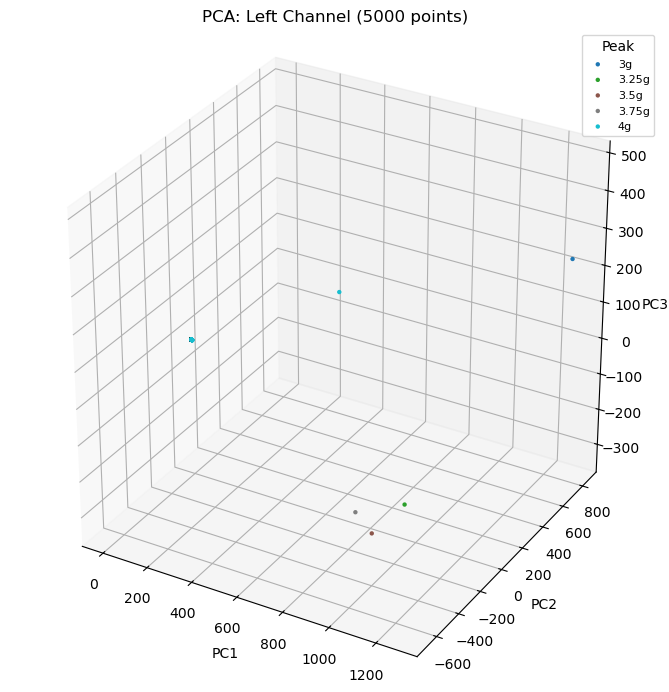

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plot_pca_3d_scores(scores, labels, title="PCA: Left Channel", draw_centroids=False):
    """
    scores : (T, 3) ndarray  -- PCA scores (PC1, PC2, PC3)
    labels : (T,) list/ndarray of floats or ints (e.g., 3, 3.25, 3.5, 3.75, 4.0)
    """
    scores = np.asarray(scores, dtype=np.float32)
    labels = np.asarray(labels)

    assert scores.ndim == 2 and scores.shape[1] == 3, f"Expected (T,3), got {scores.shape}"
    assert scores.shape[0] == len(labels), "Scores/labels length mismatch."

    uniq = np.unique(labels)
    cmap = plt.cm.get_cmap('tab10', max(1, len(uniq)))
    color_lut = {u: cmap(i) for i, u in enumerate(uniq)}

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    # scatter all points per label group (smaller marker + some transparency for 5k points)
    for u in uniq:
        m = labels == u
        ax.scatter(scores[m, 0], scores[m, 1], scores[m, 2],
                   label=f"{u:g}g", s=10, alpha=1, edgecolors='none', c=[color_lut[u]])

    # optional centroids
    if draw_centroids:
        for u in uniq:
            m = labels == u
            c = scores[m].mean(axis=0)
            ax.scatter(c[0], c[1], c[2], marker='X', s=120, c=[color_lut[u]], edgecolor='k', linewidth=0.6)
            ax.text(c[0], c[1], c[2], f"{u:g}", fontsize=9)

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.grid(alpha=0.25)
    ax.legend(title="Peak", fontsize=8)
    ax.set_box_aspect((1, 1, 1))  # equal proportions
    plt.tight_layout()
    plt.show()

# === call it ===
plot_pca_3d_scores(left_channel_pca, left_labels, title="PCA: Left Channel (5000 points)")


---

In [ ]:
# ============================================================
# Time-varying presentation of precomputed bundles (5 × 1 s)
#  - Sequence: left_t1 → left_t2 → left_t3 → left_t4 → left_t5
#  - Each held for 1.0 s, total sim time = 5.0 s
#  - "Left channel wins" in every segment (as built by you)
# ============================================================

import nengo
import numpy as np
from nengo.processes import Piecewise

# If your BG class lives elsewhere, adjust the import:
from bg_model import BasalGanglia  # <-- use your actual import path

# -------------------------
# Assumes you already have:
#  - n_actions_park
#  - dnf_params_park
#  - dnf_encoders_park (if your BG needs encoders)
#  - left_t1, left_t2, left_t3, left_t4, left_t5
# (from the code you posted)
# -------------------------

# ================================================
# 1. Define continuous force domain & SSP encoder
# ================================================
n_actions_park = 2
domain_force_park = np.arange(0, 15, 0.01).reshape(-1, 1) # Shape: (1500, 1)
ssp_dim_park = 512

# SSP encoder for scalar force values
ssp_encoder_park = RandomSSPSpace(
    domain_dim=1,
    ssp_dim=ssp_dim_park,
    rng=np.random.RandomState(0),
    length_scale=0.5
)
# Convert domain values to high-dimensional SSPs
domain_phis_park = ssp_encoder_park.encode(domain_force_park)  # shape: (1500, 512)
# print(domain_phis.shape)

# Place cell encoders for Nengo ensembles
low = 0
high = 15
width = high - low
places_park = np.arange(low, high, width/(domain_force_park.shape[0]))
dnf_encoders_park = np.asarray(ssp_encoder_park.encode(places_park.reshape(-1, 1))).squeeze() # Shape: (1500, 512)
# print(dnf_encoders.shape) # (512, 1500)

# ================================================
# 2. DNF Parameters
# ================================================
dnf_params_park = {
            'h'       : -3.009416816439706,
            'global_inh'      : 8.641108231311897,
            'tau'             : 0.04706404390267922,
            'exc'             : 9.421285790349613,
            'inh'             : 1.4841093480380807,
            'exc_w'           : 8.534993467227224,
            'inh_w'           : 4.748154014869723,
            'dt'              : 0.001, 
            'c_noise'         : 1.0,
            'shape'           : [(n_actions_park, 1500)], 
            'beta'            : 4,
    }



# ================================================
# 3. Generate two bundle vectors via Beta PDFs
# ================================================
# Define peak locations
peak_locations_left = [3, 3.25, 3.5, 3.75, 4]
peak_locations_right = [12, 12.25, 12.5, 12.75, 13]

# Generate beta PDFs
left_distributions = []
right_distributions = []
for i in range(len(peak_locations_left)):
    left_distributions.append(beta_with_peak(domain=domain_force_park, peak=peak_locations_left[i], scale=15, k=25))
    right_distributions.append(beta_with_peak(domain=domain_force_park, peak=peak_locations_right[i], scale=15, k=25))

# ========================================
# 4. Salience values for actions
# ========================================
salience_left = [0.9, 0.6]
salience_right = [0.6, 0.9]

# ========================================
# 5. Create bundles for the 5 sets of trials -- foreground data 
# ========================================
# In all cases left channel wins
left_t1 = Utility.to_bundle(Utility.to_scale(salience_left, Utility.to_normalize([left_distributions[0], right_distributions[0]])), domain_phis_park)
left_t2 = Utility.to_bundle(Utility.to_scale(salience_left, Utility.to_normalize([left_distributions[1], right_distributions[1]])), domain_phis_park)
left_t3 = Utility.to_bundle(Utility.to_scale(salience_left, Utility.to_normalize([left_distributions[2], right_distributions[2]])), domain_phis_park)
left_t4 = Utility.to_bundle(Utility.to_scale(salience_left, Utility.to_normalize([left_distributions[3], right_distributions[3]])), domain_phis_park)
left_t5 = Utility.to_bundle(Utility.to_scale(salience_left, Utility.to_normalize([left_distributions[4], right_distributions[4]])), domain_phis_park)
# In all cases right channel wins
right_t1 = Utility.to_bundle(Utility.to_scale(salience_right, Utility.to_normalize([left_distributions[0], right_distributions[0]])), domain_phis_park)
right_t2 = Utility.to_bundle(Utility.to_scale(salience_right, Utility.to_normalize([left_distributions[1], right_distributions[1]])), domain_phis_park)
right_t3 = Utility.to_bundle(Utility.to_scale(salience_right, Utility.to_normalize([left_distributions[2], right_distributions[2]])), domain_phis_park)
right_t4 = Utility.to_bundle(Utility.to_scale(salience_right, Utility.to_normalize([left_distributions[3], right_distributions[3]])), domain_phis_park)
right_t5 = Utility.to_bundle(Utility.to_scale(salience_right, Utility.to_normalize([left_distributions[4], right_distributions[4]])), domain_phis_park)

In [70]:
left_t1[0].shape

(512,)

In [71]:
import nengo
import numpy as np
from nengo import Node, Connection
from nengo.processes import Piecewise
# If the BG class is already in scope, you don't need this import.
# from bg_model import BasalGanglia

# Build BG exactly as your code expects
bg = BasalGanglia(
    n_actions=n_actions_park,           # = 2
    dnf_parameters=dnf_params_park,
    encoders=dnf_encoders_park,         # shape: (1500, 512)
    dnf_neurons=1500
)

# --- Each left_tk is a 2-item list: [bundle for channel 0, bundle for channel 1]
#     We schedule per-channel bundles, stepping every 1s for 5s total.
ch0_schedule = {
    0.0: np.asarray(left_t1[0]),
    1.0: np.asarray(left_t2[0]),
    2.0: np.asarray(left_t3[0]),
    3.0: np.asarray(left_t4[0]),
    4.0: np.asarray(left_t5[0]),
}
ch1_schedule = {
    0.0: np.asarray(left_t1[1]),
    1.0: np.asarray(left_t2[1]),
    2.0: np.asarray(left_t3[1]),
    3.0: np.asarray(left_t4[1]),
    4.0: np.asarray(left_t5[1]),
}
sim_time = 5.0  # seconds

with nengo.Network(label="BG 5s scheduled input") as model:
    model.add(bg)

    # Two per-channel input nodes that deliver the correct 512D bundle each second
    in_ch0 = Node(Piecewise(ch0_schedule), size_out=bg.ssp_dim, label="in_ch0")
    in_ch1 = Node(Piecewise(ch1_schedule), size_out=bg.ssp_dim, label="in_ch1")

    # Dopamine (constant here; make it Piecewise too if you want it to vary)
    dopamine_node = Node(output=0.2, size_out=1, label="dopamine")

    # Output sink (matches your simulate() wiring)
    out_node = Node(size_in=bg.ssp_dim * bg.n_actions, label="bg_out_sink")

    # Wire inputs → BG cortex_inputs
    Connection(in_ch0, bg.cortex_inputs[0], synapse=None)
    Connection(in_ch1, bg.cortex_inputs[1], synapse=None)

    # Dopamine → BG
    Connection(dopamine_node, bg.dopamine, synapse=None)

    # BG → sink
    Connection(bg.bg_out, out_node, synapse=None)

    # --- Probes (same shape/keys as your simulate())
    p_in_ch0 = nengo.Probe(in_ch0, synapse=None)
    p_in_ch1 = nengo.Probe(in_ch1, synapse=None)

    p_d1_in   = nengo.Probe(bg.d1_dnf.g.neurons, 'input', synapse=None)
    p_d1_neur = nengo.Probe(bg.d1_dnf.g.neurons, synapse=None)

    p_d2_in   = nengo.Probe(bg.d2_dnf.g.neurons, 'input', synapse=None)
    p_d2_neur = nengo.Probe(bg.d2_dnf.g.neurons, synapse=None)

    p_out = nengo.Probe(out_node, synapse=None)

# Run for 5 seconds (five 1-second plateaus)
with nengo.Simulator(model) as sim:
    sim.run(sim_time)

# Package results to match bg.simulate() return format
data_5s = {
    'bundle_ins': [sim.data[p_in_ch0], sim.data[p_in_ch1]],  # per action channel
    'd1_input':   sim.data[p_d1_in],
    'd1_neuron':  sim.data[p_d1_neur],
    'd2_input':   sim.data[p_d2_in],
    'd2_neuron':  sim.data[p_d2_neur],
    'bundle_out': sim.data[p_out],
    'custom_probes': {},  # fill if you added bg.add_probe(...) and mirrored those probes here
}

# Now use `data_5s` in your existing analysis pipeline.


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

/Users/priyadarshinisaha/anaconda3/envs/bgmodel/lib/python3.10/site-packages/nengo/neurons.py:489: RuntimeWarning: overflow encountered in exp
  output[...] = (1.0 / self.tau_ref) / (1 + np.exp(-J))


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

In [100]:
# Running for background noise
import nengo
import numpy as np
from nengo import Node, Connection
from nengo.processes import WhiteSignal
# If needed:
# from bg_model import BasalGanglia

# ---------------------------
# Params (tweak as you like)
# ---------------------------
duration = 5.0      # seconds of background noise
high     = 10.0     # Hz cutoff for band-limited noise
rms      = 1.0      # overall noise scale (tune vs. SSP magnitudes)
seed     = 0        # base seed (each channel uses seed+i)

# ---------------------------
# Construct the noise-driven network
# ---------------------------
with nengo.Network(label="BG background noise") as model:
    model.add(bg)

    # One band-limited WhiteSignal per action channel (matches SSP 512-D)
    noise_nodes = []
    for i in range(bg.n_actions):
        noise_proc = WhiteSignal(period=duration, high=high, rms=rms, seed=seed + i)
        node = Node(noise_proc, size_out=bg.ssp_dim, label=f"noise_in_{i}")
        noise_nodes.append(node)
        Connection(node, bg.cortex_inputs[i], synapse=None)

    # Baseline dopamine (0); make this a Node(0.0) to match your simulate_noise()
    dopamine_node = Node(output=0.0, size_out=1, label="dopamine_0")
    Connection(dopamine_node, bg.dopamine, synapse=None)

    # Output sink (same shape as simulate/simulate_noise)
    out_node = Node(size_in=bg.ssp_dim * bg.n_actions, label="bg_out_sink")
    Connection(bg.bg_out, out_node, synapse=None)

    # ---------------------------
    # Probes (keys/shape match your simulate*() returns)
    # ---------------------------
    p_ins = [nengo.Probe(noise_nodes[i], synapse=None) for i in range(bg.n_actions)]

    p_d1_in   = nengo.Probe(bg.d1_dnf.g.neurons, 'input', synapse=None)
    p_d1_neur = nengo.Probe(bg.d1_dnf.g.neurons, synapse=None)

    p_d2_in   = nengo.Probe(bg.d2_dnf.g.neurons, 'input', synapse=None)
    p_d2_neur = nengo.Probe(bg.d2_dnf.g.neurons, synapse=None)

    p_out = nengo.Probe(out_node, synapse=None)

# ---------------------------
# Run
# ---------------------------
with nengo.Simulator(model) as sim:
    sim.run(duration)

# ---------------------------
# Package results like bg.simulate_noise()
# ---------------------------
noise_run = {
    'bundle_ins': [sim.data[p] for p in p_ins],  # list length = n_actions, each (T, 512)
    'd1_input':   sim.data[p_d1_in],
    'd1_neuron':  sim.data[p_d1_neur],
    'd2_input':   sim.data[p_d2_in],
    'd2_neuron':  sim.data[p_d2_neur],
    'bundle_out': sim.data[p_out],
    'custom_probes': {},  # if you want custom ones, add explicit probes above and fill here
}


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

In [74]:
data_5s['d1_neuron'].shape
noise_run['d1_neuron'].shape

(5000, 3000)

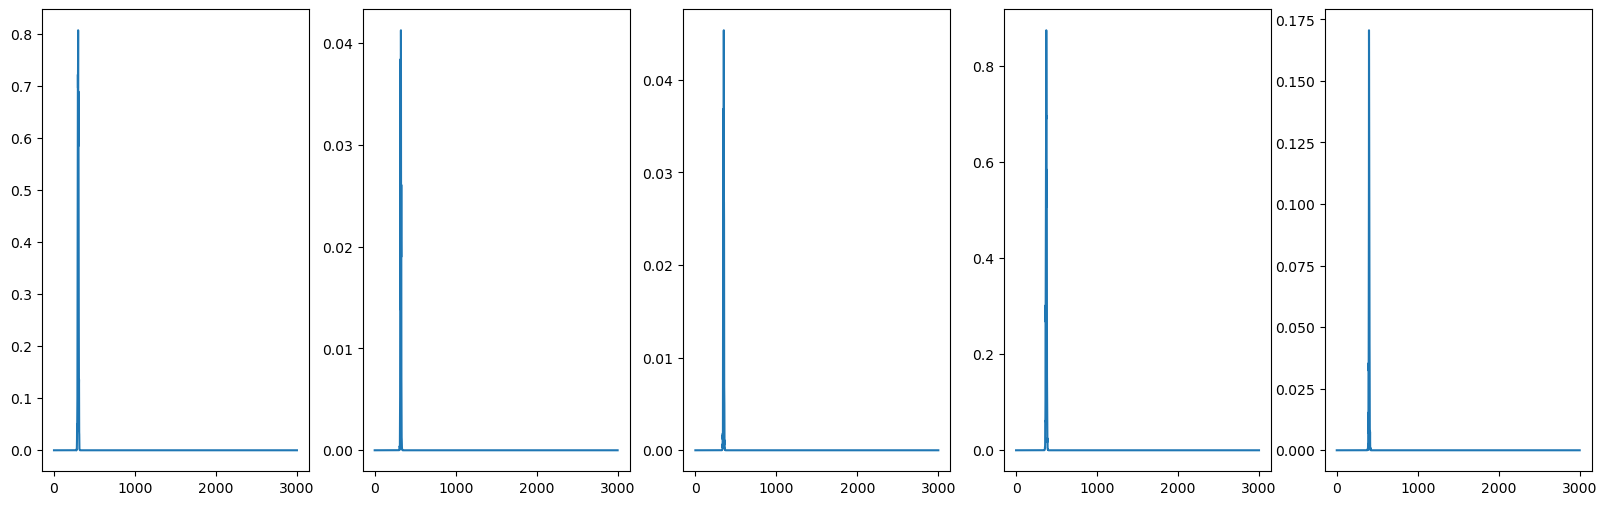

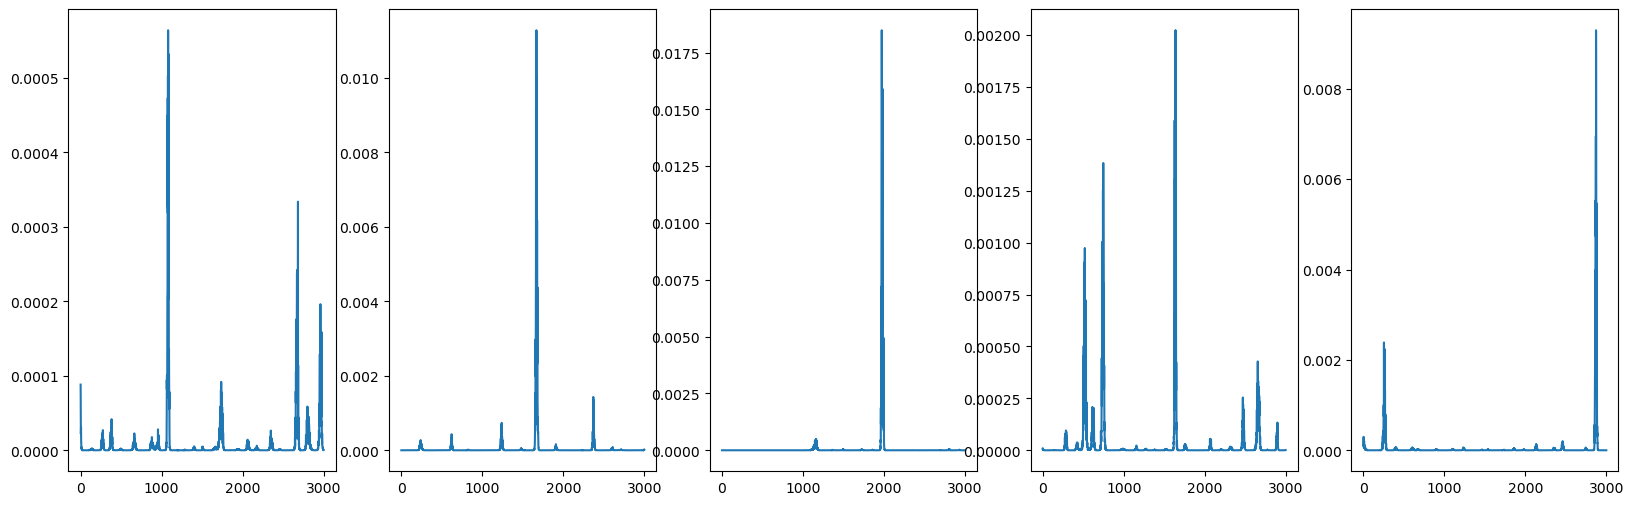

In [101]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
axes[0].plot(data_5s['d1_neuron'][998, :])
axes[1].plot(data_5s['d1_neuron'][1998, :])
axes[2].plot(data_5s['d1_neuron'][2998, :])
axes[3].plot(data_5s['d1_neuron'][3998, :])
axes[4].plot(data_5s['d1_neuron'][4998, :])

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
axes[0].plot(noise_run['d1_neuron'][998, :])
axes[1].plot(noise_run['d1_neuron'][1998, :])
axes[2].plot(noise_run['d1_neuron'][2998, :])
axes[3].plot(noise_run['d1_neuron'][3998, :])
axes[4].plot(noise_run['d1_neuron'][4998, :])

In [144]:
left_target_5s = data_5s['d1_neuron'][:, :1500] # 5000, 1500
left_3_5s = data_5s['d1_neuron'][:1000, :1500] # 1000, 1500
background_5s = np.vstack([left_3_5s, left_3_5s, left_3_5s, left_3_5s, left_3_5s]) # 5000, 1500

left_labels_5s = (1000) * [3.0] + (1000) * [3.25] + (1000) * [3.50] + (1000) * [3.75] + (1000) * [4.0]
print(len(left_labels_5s))
print(left_labels_5s[0])

5000
3.0


In [ ]:
# cPCA
cPCA_model = CPCA(n_components=3, standardize=False)
cpca_5s_projected, alpha_left_5s = cPCA_model.fit_transform(foreground=left_target_5s, background=background_5s, active_labels=left_labels_5s, return_alphas=True)


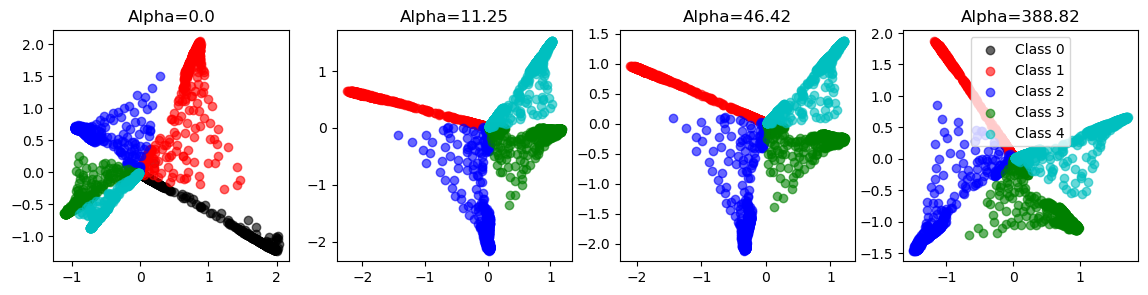

TypeError: cannot unpack non-iterable NoneType object

In [148]:
cPCA_model = CPCA(n_components=2, standardize=False)
cpca_5s_projected, alpha_left_5s = cPCA_model.fit_transform(foreground=left_target_5s, background=background_5s, plot = True, active_labels=left_labels_5s, return_alphas=True)

In [127]:
cpca_5s_projected[0].shape

(5000, 3)

In [ ]:
%matplotlib notebook

(4,)


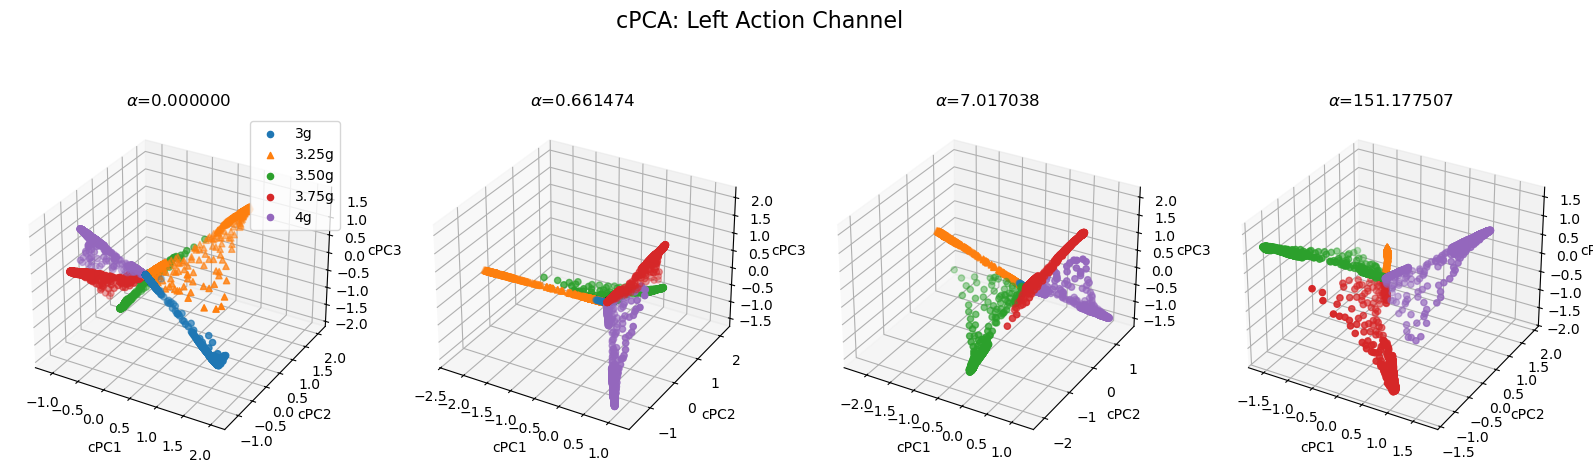

In [147]:
# Plot cPCA
%matplotlib notebook
fig, axes = plt.subplots(1, len(alpha_left), subplot_kw={'projection': '3d'}, figsize=(20, 6))
print(axes.shape)
def projected_data_3dplots(axes, data, alphas, labels, titles):
    for i in range(len(alphas)):
        # convert the data into real data 
        X = to_real(data[i])
        graph_labels = np.asarray(labels)
        f3 = graph_labels == 3.0
        f325 = graph_labels == 3.25
        f350 = graph_labels == 3.50
        f375 = graph_labels == 3.75
        f4 = graph_labels == 4.0

        # plot 
        axes[i].scatter(X[f3, 0],  X[f3, 1],  X[f3, 2],  label='3g',  marker='o')
        axes[i].scatter(X[f325, 0], X[f325, 1], X[f325, 2], label='3.25g', marker='^')
        axes[i].scatter(X[f350, 0], X[f350, 1], X[f350, 2], label='3.50g', marker='o')
        axes[i].scatter(X[f375, 0], X[f375, 1], X[f375, 2], label='3.75g', marker='o')
        axes[i].scatter(X[f4, 0], X[f4, 1], X[f4, 2], label='4g', marker='o')
        axes[i].set_title(r'$\alpha$=' + f'{alpha_left[i]:2f}')
        axes[i].set_xlabel('cPC1')
        axes[i].set_ylabel('cPC2')
        axes[i].set_zlabel('cPC3')
        


projected_data_3dplots(axes, cpca_5s_projected, alpha_left_5s, left_labels_5s, titles=[])
axes[0].legend(loc='upper right')
# projected_data_3dplots(axes[1, :], projected_data_right, alpha_right, a2_labels, titles=[])

fig.text(0.5, 0.92, "cPCA: Left Action Channel", ha='center', fontsize=16)
# fig.text(0.5, 0.46, "cPCA: Right Action Channel", ha='center', fontsize=16)
plt.show()

In [ ]:
# PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
pca_model_5s = PCA(n_components=3)

pca_5s_projected = pca_model_5s.fit_transform(scaler.fit_transform(left_target_5s)) # 5000, 3

In [ ]:
# PCA plot fig = plt.figure() ax = plt.axes(projection='3d') x = pca_5s_projected[:, 0] y = pca_5s_projected[:, 1] z = pca_5s_projected[:, 2] ax.scatter(x, y, x, 'green') plt.show()

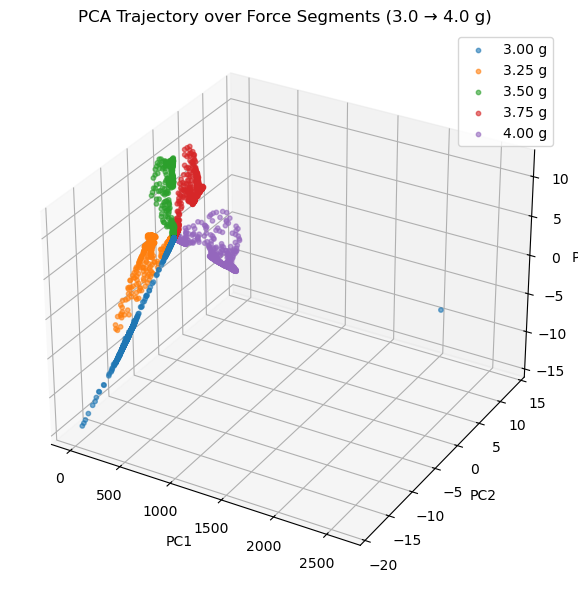

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Your PCA data (5000, 3)
# pca_5s_projected = ...

# Define segment meta
n_per_seg = 1000
force_values = [3.0, 3.25, 3.5, 3.75, 4.0]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot each 1 s (1000 sample) segment separately
for i, f in enumerate(force_values):
    start, end = i * n_per_seg, (i + 1) * n_per_seg
    segment = pca_5s_projected[start:end]

    # Scatter for this segment
    ax.scatter(segment[:, 0], segment[:, 1], segment[:, 2],
               s=10, color=colors[i], alpha=0.6, label=f'{f:.2f} g')

    # Add label at centroid
    # centroid = segment.mean(axis=0)
    # ax.text(centroid[0], centroid[1], centroid[2],
            # f'{f:.2f}', color='k', fontsize=10, weight='bold')

# Axis labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA Trajectory over Force Segments (3.0 → 4.0 g)')
ax.legend()
plt.tight_layout()
plt.show()
